## SARGEO

In [37]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
sargeo_path = "/scale/project/ifremer-isi-jumeaunumerique/SARGEO/prototype/v01r02/cyclobs"    #le chemin dans datarmor
main_path=sargeo_path
os.chdir(main_path)   #changer le répertoire de travail vers le chemin du base de données SARGEO

In [39]:
cyclone = list(os.listdir(main_path))[10]    #choisir un cyclone 
cyclone_path = os.path.join(main_path, cyclone)   #le chemin du cyclone choisi
print(os.listdir(cyclone_path))
irwin_cyclone_path = os.path.join(cyclone_path, "IRWIN")  #le chemin du dossier IRWIN du cyclone choisi
os.listdir(irwin_cyclone_path)

['WV', 'IRWIN']


['rcm3-sclnd-owi-cm-20241026t141619-20241026t141735-00003-______ll_gd_GEO-IRWIN.nc',
 'rcm1-sc50mb-owi-cm-20241023t012355-20241023t012513-00003-______ll_gd_GEO-IRWIN.nc',
 'rcm3-sc50mc-owi-cm-20241024t020432-20241024t020550-00003-______ll_gd_GEO-IRWIN.nc',
 'rcm3-sclnc-owi-cm-20241025t140906-20241025t141023-00003-______ll_gd_GEO-IRWIN.nc',
 'rcm3-sclnd-owi-cm-20241027t142324-20241027t142441-00003-______ll_gd_GEO-IRWIN.nc',
 'rcm1-sc50mb-owi-cm-20241023t132045-20241023t132202-00003-______ll_gd_GEO-IRWIN.nc',
 'rcm3-sclna-owi-cm-20241024t140117-20241024t140232-00003-______ll_gd_GEO-IRWIN.nc',
 'rcm3-sclna-owi-cm-20241025t021249-20241025t021404-00003-______ll_gd_GEO-IRWIN.nc',
 'rcm2-sc50ma-owi-cm-20241021t123254-20241021t123411-00003-______ll_gd_GEO-IRWIN.nc',
 's1a-ew-owi-cm-20241025t021734-20241025t021838-000003-06E34A_ll_gd_GEO-IRWIN.nc']

In [40]:
irwin_0_path = os.path.join(irwin_cyclone_path, list(os.listdir(irwin_cyclone_path))[0])  #le chemin du premier fichier IRWIN
ds = xr.open_dataset(irwin_0_path)  #ouvrir le fichier netcdf avec xarray
print(list(ds.data_vars.keys())) #afficher les variables du fichier netcdf
print("---- présenattaion du fichier netcdf -----------")
print(ds.data_vars)
# print(ds["storm_latitude"])

['time', 'sar_acquisition_time', 'center_extrapolation_flag', 'availability_flag', 'IRWIN', 'vmax_bt', 'rmax_bt', 'mslp_bt', 'time_diff', 'storm_longitude', 'storm_latitude', 'platform_longitude', 'platform_latitude', 'platform_altitude', 'platform_name', 'channel', 'sid']
---- présenattaion du fichier netcdf -----------
Data variables:
    time                       (t_rel) datetime64[ns] 72B ...
    sar_acquisition_time       datetime64[ns] 8B ...
    center_extrapolation_flag  (t_rel) int64 72B ...
    availability_flag          (t_rel) int64 72B ...
    IRWIN                      (t_rel, y, x) float32 36MB ...
    vmax_bt                    (t_rel) float32 36B ...
    rmax_bt                    (t_rel) float32 36B ...
    mslp_bt                    (t_rel) float32 36B ...
    time_diff                  (t_rel) timedelta64[ns] 72B ...
    storm_longitude            (t_rel) float32 36B ...
    storm_latitude             (t_rel) float32 36B ...
    platform_longitude         (t_rel) f

/tmp/ipykernel_2889389/1290626548.py:2: FutureWarning: In a future version, xarray will not decode the variable 'time_diff' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(irwin_0_path)  #ouvrir le fichier netcdf avec xarray


Le canal IRWIN sélectionné est : IRWIN


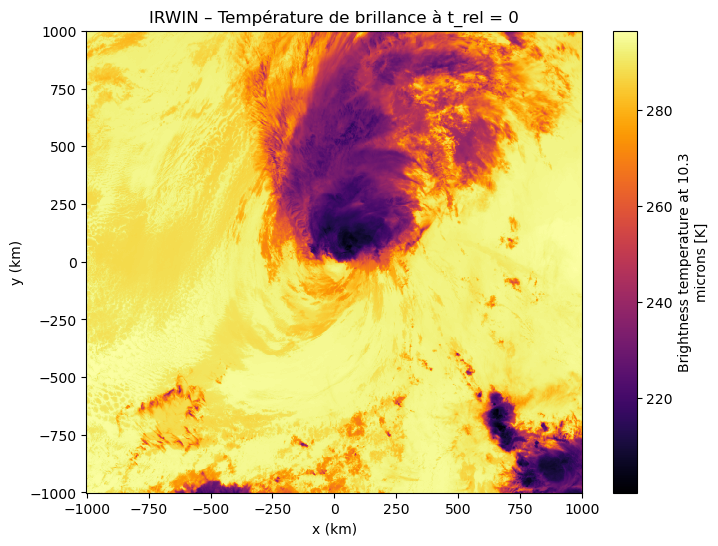

In [41]:
irwin_channel = list(ds.data_vars.keys())[4]  # selectionner la variable IRWIN d'indice 4
print(f"Le canal IRWIN sélectionné est : {irwin_channel}")
plt.figure(figsize=(8, 6)) 
ds[irwin_channel].sel(t_rel=0).plot.imshow(cmap='inferno') #afficher l'image de la température de brillance à t_rel = 0
plt.title("IRWIN – Température de brillance à t_rel = 0")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.show()

In [43]:
wv_path  = os.path.join(cyclone_path, "WV")   #le chemin du dossier WV du cyclone choisi
wv_à_path = os.path.join(wv_path, list(os.listdir(wv_path))[0])   #le chemin du premier fichier WV
ds = xr.open_dataset(wv_à_path)   #ouvrir le fichier netcdf avec xarray
# print(list(ds.data_vars.keys()))  #afficher les variables du fichier netcdf
wv_channel = list(ds.data_vars.keys())[4]
# print(len(os.listdir(irwin_cyclone_path)))
# os.listdir(wv_path)

/tmp/ipykernel_2889389/643737020.py:3: FutureWarning: In a future version, xarray will not decode the variable 'time_diff' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(wv_à_path)   #ouvrir le fichier netcdf avec xarray


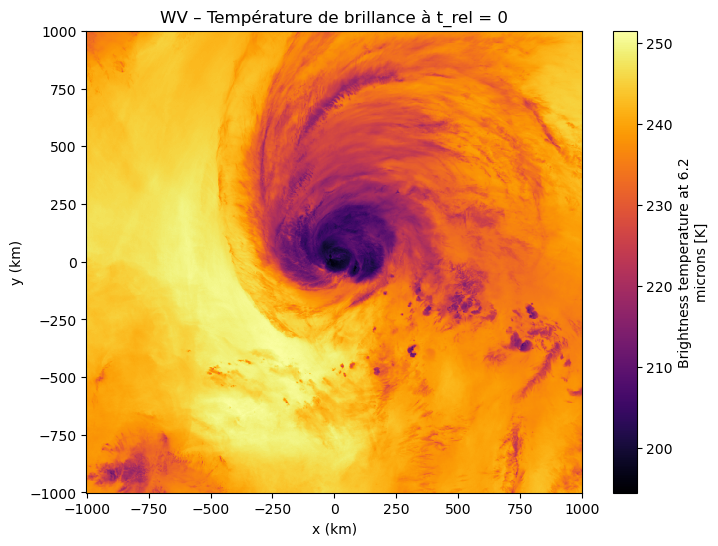

In [ ]:
plt.figure(figsize=(8, 6))
ds[wv_channel].sel(t_rel=0).plot.imshow(cmap='inferno')  #afficher l'image du canal WV à t_rel = 0
plt.title("WV – Température de brillance à t_rel = 0")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.show()

In [45]:
import xarray as xr
ds_sar = xr.open_dataset("/home/datawork-cersat-public/cache/public/ftp/project/sarwing/processings/grdwind+windir_2025v6v12_2v0_0v3v9_0v0v6_0v0v6_1v4v3_1v0v15_1v0v10_1v2v5_1v2v2_1v1v1_1v2v1/cmod5n_ecmwf_norecal_rs2rcmgmfv4_28052025/rcm-1/L2M/sc50ma/rcm-1_sc50ma/2025/297/RCM1_OK3869301_PK3871711_1_SC50MA_20251024_105534_HH_HV_GRD/rcm1-sc50ma-owi-cm-20251024t105532-20251024t105647-00003-xxxxx.nc")

# print(ds_sar.data_vars)   #afficher les variables du fichier netcdf

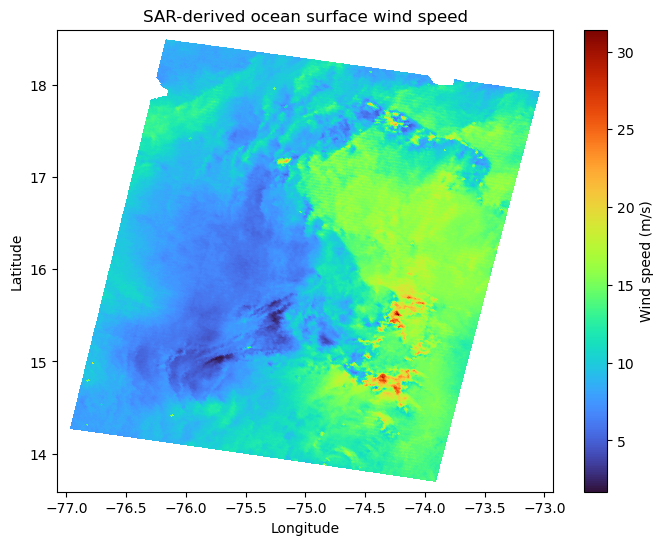

In [46]:
plt.figure(figsize=(8,6))
plt.pcolormesh(ds_sar["owiLon"], ds_sar["owiLat"], ds_sar["owiWindSpeed"], cmap="turbo")  #afficher la carte de la vitesse du vent
plt.colorbar(label="Wind speed (m/s)")
plt.title("SAR-derived ocean surface wind speed")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Script pour créer la base de données SARGEO en csv

In [ ]:
# #creer la base de données excel du SARGEO 
# import os
# import xarray as xr
# import pandas as pd

# # --- Dossier racine SARGEO ---

# # --- Liste des cyclones ---
# cyclones = os.listdir(sargeo_path)

# infos = []

# for cyclone in cyclones:
#     cyclone_path = os.path.join(sargeo_path, cyclone)
#     if not os.path.isdir(cyclone_path):
#         continue

#     # print(f"🌀 Traitement du cyclone : {cyclone}")

#     # --- On regarde s'il y a les sous-dossiers IRWIN et WV ---
#     for subdir in ["IRWIN", "WV"]:
#         sub_path = os.path.join(cyclone_path, subdir)
#         if not os.path.exists(sub_path):
#             # print(f"  ⚠️ Pas de dossier {subdir} pour {cyclone}")
#             continue

#         # --- Liste des fichiers NetCDF ---
#         nc_files = [f for f in os.listdir(sub_path) if f.endswith(".nc")]
#         # print(f"  📁 {subdir} → {len(nc_files)} fichiers trouvés")

#         for nc_file in nc_files:
#             file_path = os.path.join(sub_path, nc_file)
#             try:
#                 ds = xr.open_dataset(file_path)

#                 # Vérifie que les champs existent
#                 lat_centre = float(ds["storm_latitude"].values[0]) if "storm_latitude" in ds else None
#                 lon_centre = float(ds["storm_longitude"].values[0]) if "storm_longitude" in ds else None
#                 time = str(ds["sar_acquisition_time"].values) if "sar_acquisition_time" in ds else None

#                 infos.append({
#                     "cyclone": cyclone,
#                     "canal": subdir,
#                     "fichier": nc_file,
#                     "lat_centre": lat_centre,
#                     "lon_centre": lon_centre,
#                     "sar_acquisition_time": time
#                 })

#                 ds.close()

#             except Exception as e:
#                 print(f"  ⚠️ Erreur avec {file_path} : {e}")

# # --- Conversion en DataFrame ---
# df = pd.DataFrame(infos)

# # --- Sauvegarde CSV ---
# output_csv = "/home1/datahome/mtannaou/alternance/excels/SARGEO_cyclones.csv"
# os.makedirs(os.path.dirname(output_csv), exist_ok=True)
# df.to_csv(output_csv, index=False)

# print(f"\nExtraction terminée ! Fichier sauvegardé : {output_csv}")
# print(f"Total : {len(df)} fichiers traités.")
